
<div style="background-color: #000000;
            color: #e10600;
            font-weight: bold;
            padding: 15px;
            border-radius: 18px;
            text-align: center;
            font-size: 35px;
            border: 3px solid #e10600;
            box-shadow: 0 0 10px #e10600,
                        0 0 20px rgba(225,6,0,0.7);">
🧠ALZHEIMER MRI DATASET
</div>

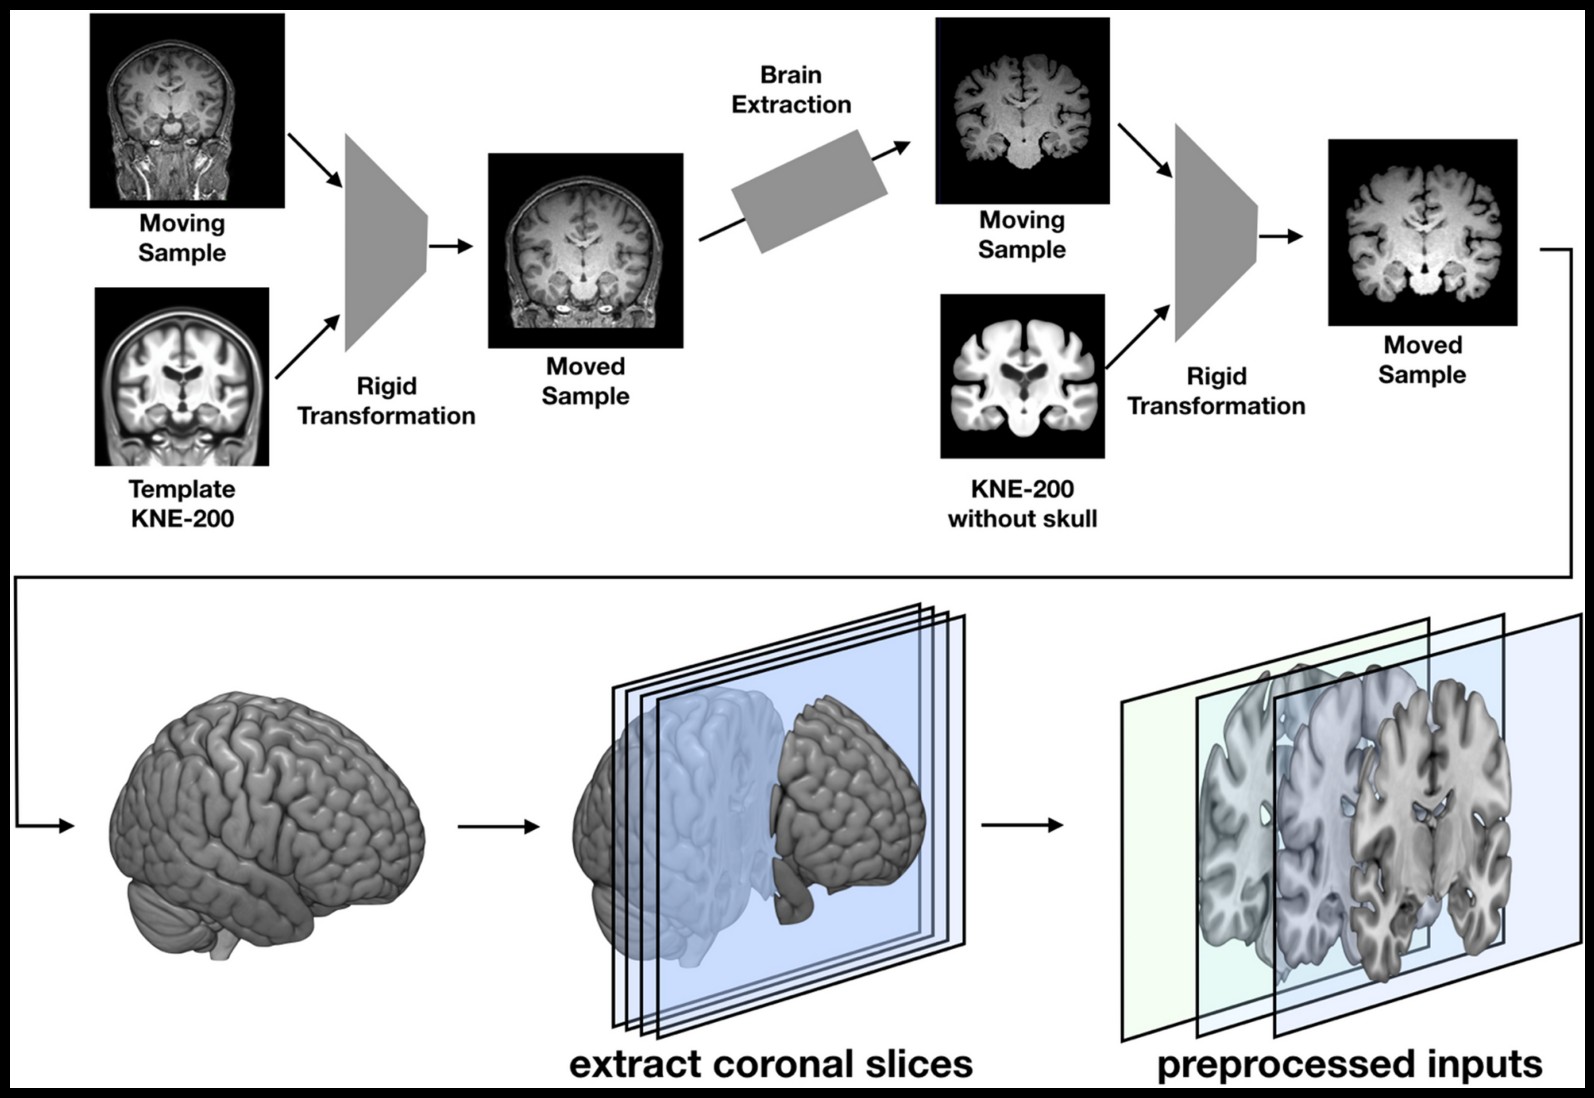

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r"C:\Users\Hp\Pictures\41598_2020_79243_Fig1_HTML.png")

plt.figure(figsize=(22, 14))   # Bigger = larger image
plt.imshow(img)
plt.axis('off')
plt.show()

<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 28px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
📚 IMPORTING REQUIRED LIBRARIES & MODULES
</div>

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical
import os
from tensorflow.keras.optimizers import Adam


<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 28px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
Encoding
</div>

In [2]:
encoder = OneHotEncoder()

# 4 classes → 0,1,2,3
encoder.fit([[0],[1],[2],[3]])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'



<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 28px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
DataSet reading and cleaning
</div>

In [3]:


data = []
result = []

dataset_path = r"C:\Users\Hp\Downloads\archive\Alzheimer_MRI_4_classes_dataset"

class_map = {
    "MildDemented": 0,
    "ModerateDemented": 1,
    "NonDemented": 2,
    "VeryMildDemented": 3
}

for class_name in class_map:
    class_folder = os.path.join(dataset_path, class_name)
    
    for file in os.listdir(class_folder):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            
            img_path = os.path.join(class_folder, file)
            img = Image.open(img_path).convert("RGB")   # 🔥 IMPORTANT FIX
            img = img.resize((128,128))
            img = np.array(img)
            
            data.append(img)
            result.append(class_map[class_name])

data = np.array(data)
result = np.array(result)

# Normalize
data = data / 255.0

print("Total images loaded:", len(data))

Total images loaded: 6400


<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 28px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
Model Building
</div>

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    data,
    result,
    test_size=0.2,
    random_state=42,
    stratify=result
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (5120, 128, 128, 3)
Test shape: (1280, 128, 128, 3)


<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 26px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
 CONVOLUTIONAL NEURAL NETWORK (CNN) MODEL ARCHITECTURE
</div>

In [5]:
model = Sequential()

# 🔹 Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 🔹 Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 🔹 Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 🔹 Flatten Layer
model.add(Flatten())

# 🔹 Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# 🔹 Output Layer (4 Classes)
model.add(Dense(4, activation='softmax'))

C:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,052 (12.61 MB)

 Trainable params: 3,305,604 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.4564 - loss: 3.3694 - val_accuracy: 0.0102 - val_loss: 69.4714
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5000 - loss: 1.1683 - val_accuracy: 0.0102 - val_loss: 33.5841
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.5000 - loss: 1.1398 - val_accuracy: 0.1945 - val_loss: 3.5253
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5000 - loss: 1.1226 - val_accuracy: 0.5000 - val_loss: 1.4234
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5000 - loss: 1.0981 - val_accuracy: 0.5102 - val_loss: 0.9996
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5000 - loss: 1.0770 - val_accuracy: 0.5000 - val_loss: 1.0080
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.5018 - loss: 1.0683 - val_accuracy: 0.5070 - val_loss: 0.9968
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.5014 - loss: 1.0594 - val_accuracy: 0.5008 -

In [9]:
score=model.evaluate(x_test,y_test,batch_size=64)
print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.5352 - loss: 0.9092

Test accuracy: 53.5%


<div style="background-color: #000000;
            color: #00aaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 15px;
            text-align: center;
            font-size: 28px;
            border: 3px solid #00aaff;
            box-shadow: 0 0 10px #00aaff,
                        0 0 20px rgba(0,170,255,0.7);">
Prediction
</div>

In [10]:
from tensorflow.keras.preprocessing import image
img=image.load_img(r"C:\Users\Hp\Downloads\archive\Alzheimer_MRI_4_classes_dataset\NonDemented\6 (5).jpg",target_size=(128, 128))
img_array =np.array(img)
img_array = img_array.reshape(1, 128, 128, 3)


In [11]:
class_names = [ "MildDemented",
    "ModerateDemented",
    "NonDemented",
    "VeryMildDemented"]

prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_label = class_names[predicted_index]

print("Predicted class:", predicted_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
Predicted class: NonDemented
